# Project 02 (medium) — reference solution: the honest model race

**Goal:** compare several model families fairly via pipeline + cross-validation, tune the
best two, and measure honestly on the test set once, right at the end.

**Data:** Breast Cancer Wisconsin (Diagnostic), built into scikit-learn — 569 samples,
30 numerical features from images of cell nuclei, target: *malignant* (0) vs. *benign* (1).

**This is the fully worked solution.** All cells have been executed. The notes marked as
tasks in the exercise notebook are answered here in prose.

## 1. Load, explore and split the data

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

print(X.shape)
print(pd.Series(y).map({0: "malignant", 1: "benign"}).value_counts(normalize=True))

(569, 30)
benign       0.627417
malignant    0.372583
Name: proportion, dtype: float64


**Task:** make the split — stratified (script 1.4: keep the class shares equal in every
split), `test_size=0.2`, `random_state=42`. From now on the test set is **not** touched
until step 6.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training: {len(X_train)}, test: {len(X_test)}")
# Mini check: the class share in the test set is close to the overall share (stratified)
print(abs(y_test.mean() - y.mean()) < 0.02)

Training: 455, test: 114
True


## 2. Baseline

Every serious model has to beat the `DummyClassifier` (always the majority class).
This is the zero line against which you can place all the CV results in a moment.

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"Dummy accuracy: {dummy.score(X_test, y_test):.3f}  (its ROC-AUC would be 0.5 - chance)")

Dummy accuracy: 0.632  (its ROC-AUC would be 0.5 - chance)


## 3. Pipelines for six model families

**Task:** build a dictionary `models = {"name": Pipeline(...), ...}` with one
`Pipeline([("scaler", StandardScaler()), ("clf", <model>)])` each for:

- `LogisticRegression` (`max_iter=5000`)
- `KNeighborsClassifier`
- `SVC` (the RBF kernel is the default; `probability=True` so that ROC curves work later)
- `DecisionTreeClassifier` (`random_state=42`)
- `RandomForestClassifier` (`random_state=42`)
- `GradientBoostingClassifier` (`random_state=42`)

Script 2.4: trees/ensembles do not need scaling, but the pipeline does no harm and keeps
the code uniform (one loop for all models).

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Logistic regression": Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000))]),
    "kNN": Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
    "SVM (RBF)": Pipeline([("scaler", StandardScaler()), ("clf", SVC(probability=True))]),
    "Decision tree": Pipeline([("scaler", StandardScaler()), ("clf", DecisionTreeClassifier(random_state=42))]),
    "Random forest": Pipeline([("scaler", StandardScaler()), ("clf", RandomForestClassifier(random_state=42))]),
    "Gradient boosting": Pipeline([("scaler", StandardScaler()), ("clf", GradientBoostingClassifier(random_state=42))]),
}

print(list(models.keys()))
print(len(models) == 6)

['Logistic regression', 'kNN', 'SVM (RBF)', 'Decision tree', 'Random forest', 'Gradient boosting']
True


## 4. A fair comparison by cross-validation

**Task:** for every model compute `cross_val_score` with `StratifiedKFold(n_splits=5,
shuffle=True, random_state=42)` and `scoring="roc_auc"` on the **training data**.
Collect the 5 scores per model (e.g. in `results = {"name": np.array([...]), ...}`)
and present them as a box plot.

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, pipeline in models.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    results[name] = scores

for name, scores in results.items():
    print(f"{name:25s}  ROC-AUC = {scores.mean():.4f} +/- {scores.std():.4f}")

Logistic regression        ROC-AUC = 0.9959 +/- 0.0050
kNN                        ROC-AUC = 0.9882 +/- 0.0081
SVM (RBF)                  ROC-AUC = 0.9956 +/- 0.0048
Decision tree              ROC-AUC = 0.9179 +/- 0.0201
Random forest              ROC-AUC = 0.9896 +/- 0.0083
Gradient boosting          ROC-AUC = 0.9918 +/- 0.0053


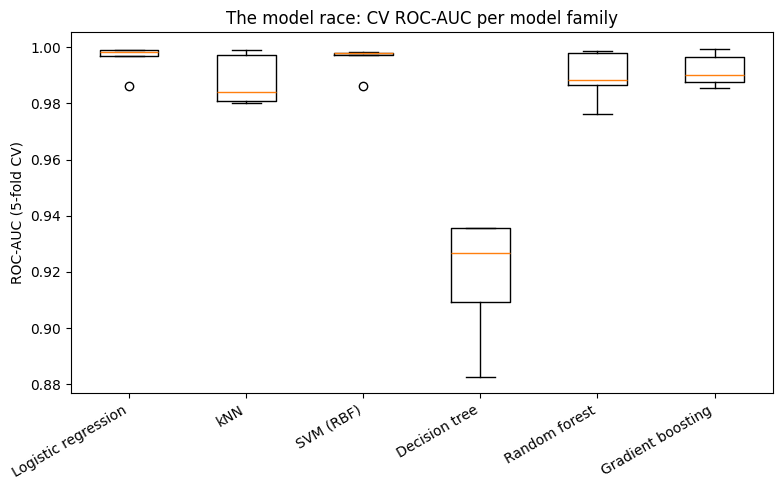

In [6]:
plt.figure(figsize=(8, 5))
plt.boxplot(results.values(), tick_labels=results.keys())
plt.xticks(rotation=30, ha="right")
plt.ylabel("ROC-AUC (5-fold CV)")
plt.title("The model race: CV ROC-AUC per model family")
plt.tight_layout()
plt.show()

**Answer:** logistic regression and gradient boosting go into tuning — they have the
highest mean CV ROC-AUC. The mean alone is not enough because a model with a marginally
better mean but a much wider box is less reliable: the difference then lies within the
fold-to-fold noise, and on new data the ranking could easily reverse. A narrow box means
the estimate is stable across the folds.

## 5. Hyperparameter tuning of the top 2

**Task:** choose your two best models from step 4. Define a parameter grid for each
(script 2.5) and tune with `GridSearchCV` (`cv=cv`, `scoring="roc_auc"`) on the
**training data**. Examples of sensible grids:

- Random forest: `clf__n_estimators`, `clf__max_depth`
- Gradient boosting: `clf__n_estimators`, `clf__learning_rate`, `clf__max_depth`
- SVM: `clf__C`, `clf__gamma`
- Logistic regression: `clf__C`

(Parameter names in the grid need the pipeline prefix `clf__`, because the classifier
sits in the pipeline under the name `"clf"`.)

In [7]:
from sklearn.model_selection import GridSearchCV

grid_1 = {"clf__C": [0.01, 0.1, 1, 10, 100]}
search_1 = GridSearchCV(models["Logistic regression"], grid_1, cv=cv, scoring="roc_auc", n_jobs=-1)
search_1.fit(X_train, y_train)

print(f"Best CV ROC-AUC (logistic regression): {search_1.best_score_:.4f}")
print(f"Best parameters: {search_1.best_params_}")

Best CV ROC-AUC (logistic regression): 0.9959
Best parameters: {'clf__C': 1}


In [8]:
grid_2 = {
    "clf__n_estimators": [100, 200, 400],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_depth": [2, 3, 4],
}
search_2 = GridSearchCV(models["Gradient boosting"], grid_2, cv=cv, scoring="roc_auc", n_jobs=-1)
search_2.fit(X_train, y_train)

print(f"Best CV ROC-AUC (gradient boosting): {search_2.best_score_:.4f}")
print(f"Best parameters: {search_2.best_params_}")

Best CV ROC-AUC (gradient boosting): 0.9938
Best parameters: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 400}


## 6. The one-off test evaluation

Only now does the test set come into play. **Task:** using `best_score_`, choose the
overall better of the two tuned models (`best_model = search_1.best_estimator_` or
`search_2.best_estimator_` — `GridSearchCV` has already refitted it on all of train).
Evaluate once on `X_test`/`y_test`: confusion matrix, classification report, ROC curve + AUC.

Chosen model: Logistic regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Test ROC-AUC: 0.9954


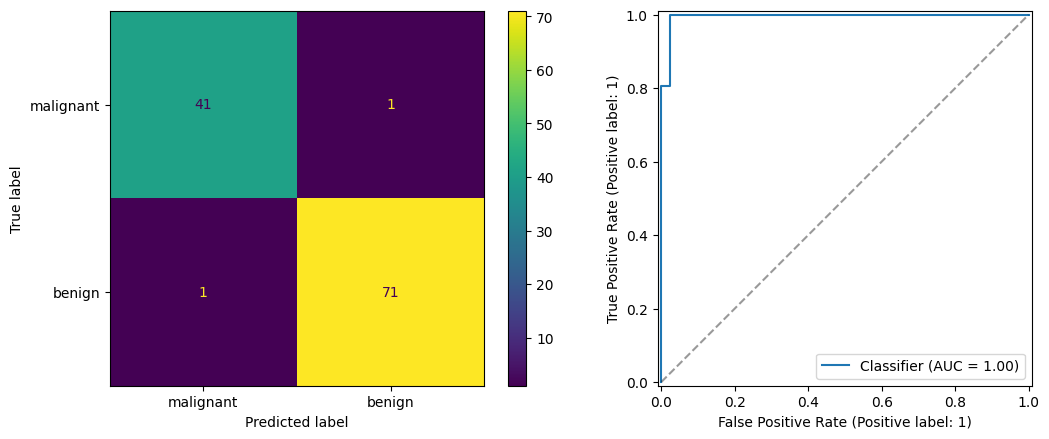

True


In [9]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, RocCurveDisplay, roc_auc_score)

best_model = search_1.best_estimator_ if search_1.best_score_ >= search_2.best_score_ else search_2.best_estimator_
print(f"Chosen model: {'Logistic regression' if best_model is search_1.best_estimator_ else 'Gradient boosting'}")

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["malignant", "benign"]))
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["malignant", "benign"], ax=axes[0])
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.tight_layout()
plt.show()

# Mini check
print(roc_auc_score(y_test, y_proba) > 0.97)

## 7. Interpretation: permutation importance

**Task:** compute `permutation_importance` (from `sklearn.inspection`) for your final
model **on the test set** (script 3.1: that is the more honest place for it than the
training data). Plot the top 10 features as a horizontal bar chart.

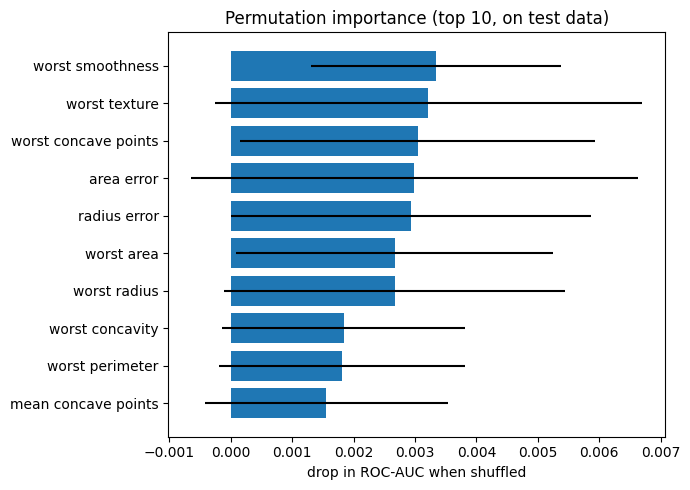

In [10]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(best_model, X_test, y_test,
                                    n_repeats=30, random_state=42, scoring="roc_auc")

order = np.argsort(importance.importances_mean)[-10:]
plt.figure(figsize=(7, 5))
plt.barh(X.columns[order], importance.importances_mean[order],
         xerr=importance.importances_std[order])
plt.xlabel("drop in ROC-AUC when shuffled")
plt.title("Permutation importance (top 10, on test data)")
plt.tight_layout()
plt.show()

**Answer:** yes. The leading features are the `worst` variants of size and shape
measures (radius, perimeter, concave points, area) — exactly the quantities pathologists
use: large, irregularly indented nuclei speak for malignancy. Note, though, that with
strongly correlated features (radius, perimeter and area measure almost the same thing)
the importance is distributed among them; a low value here does not mean "irrelevant"
(script 3.1).

## 8. Learning curve: a bias or a variance problem?

**Task:** plot the learning curve (`learning_curve`, script 2.5) for your final model:
training and CV score against the amount of training data (`train_sizes=np.linspace(0.1, 1.0, 8)`,
`scoring="roc_auc"`, `cv=cv`, on `X_train`/`y_train`). Diagnose: is more data worth it?

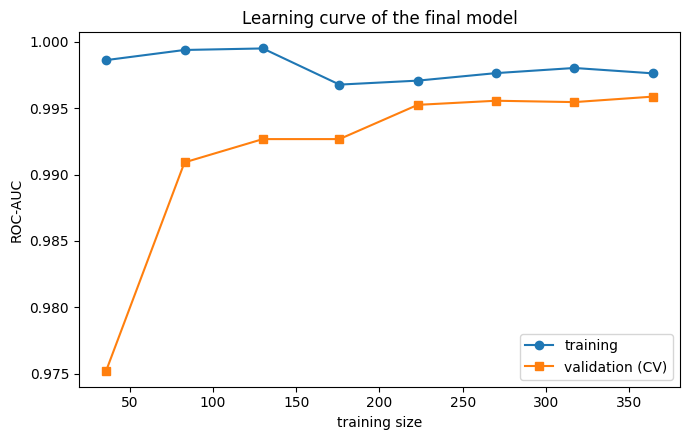

In [11]:
from sklearn.model_selection import learning_curve

sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8), cv=cv, scoring="roc_auc", n_jobs=-1)

plt.figure(figsize=(7, 4.5))
plt.plot(sizes, train_scores.mean(axis=1), marker="o", label="training")
plt.plot(sizes, val_scores.mean(axis=1), marker="s", label="validation (CV)")
plt.xlabel("training size"); plt.ylabel("ROC-AUC"); plt.legend()
plt.title("Learning curve of the final model")
plt.tight_layout()
plt.show()

**Answer:** neither, really. Both curves lie very high (ROC-AUC above 0.99) and the
gap between training and validation is small and closes further with more data. That is
the picture of a model that fits the problem: there is hardly any variance left to remove
and the bias is low. More data of the same kind would bring little — the remaining error
is close to the irreducible noise of the measurements.

## Done — what you can do now

- pack several model families consistently into pipelines
- compare models fairly by stratified cross-validation (read the mean **and** the spread)
- tune hyperparameters systematically with GridSearchCV without touching the test set
- test honestly **once** at the end and place the result in context with metrics, curves
  and permutation importance — including a learning curve diagnosis

**Reflection questions — reference answers:**

1. **Accuracy on an imbalanced data set is flattering.** With about 63 % benign, a model
   that always says "benign" already gets 63 %; accuracy would reward exactly the
   behaviour that is fatal here (missing malignant cases). ROC-AUC judges the separation
   of the classes across all thresholds and is insensitive to the class ratio.
2. **It depends on the size of the difference relative to the spread.** If the mean is
   better by 0.002 while the folds scatter by 0.02, the lead is noise — then take the more
   stable model, which is easier to reason about in production. If the lead is clearly
   larger than the spread, the wider box is acceptable.
3. **The threshold would move, not the model.** With expensive false positives you would
   demand high precision: pick the threshold on the validation data (not on the test set!)
   so that the expected costs are minimal, and report precision/recall at that threshold
   instead of at the default 0.5.

**Bonus tasks:**
1. Replace `GridSearchCV` with `RandomizedSearchCV` on a larger parameter space
   (e.g. distributions instead of lists) — compare run time and result.
2. Try `CalibratedClassifierCV` (script 3.2) on your final model and compare the
   reliability diagram before and after.